3 Classification

In [2]:
# Create dataset contain 3 classtification

import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Class 1: 100 closely grouped data points
class_1_d1 = np.random.normal(loc=5, scale=0.5, size=50)  # Feature 1
class_1_m = np.random.uniform(5.6, 10.4, size=50)  # Mass
class_1_label = np.zeros(50, dtype=int)  # Classification

# Class 2: 200 spread-out data points
# 1 left
class_2_m1 = np.random.uniform(1, 5.5, size=50)
class_2_d1 = np.random.normal(loc=5, scale=1, size=50)
# 2 top
class_2_m2 = np.random.uniform(1, 15, size=50)
class_2_d2 = np.random.normal(loc=7, scale=0.5, size=50)
#4 under
class_2_m4 = np.random.uniform(1, 15, size=50)
class_2_d4 = np.random.normal(loc=3, scale=0.5, size=50)

class_2_label = np.ones(150, dtype=int)  # Classification

# 3 right
class_3_m1 = np.random.uniform(10.5, 15, size=50)
class_3_d1 = np.random.normal(loc=5, scale=0.5, size=50)

class_3_label = np.ones(50, dtype=int) * 2

# Combine the data
diameter = np.concatenate([class_1_d1, class_2_d1, class_2_d2, class_2_d4, class_3_d1])
mass = np.concatenate([class_1_m, class_2_m1, class_2_m2, class_2_m4, class_3_m1])
labels = np.concatenate([class_1_label, class_2_label, class_3_label])

# Create DataFrame
df = pd.DataFrame({"m": mass, "d": diameter, "label": labels})
# Save as CSV
df.to_csv("D:\\Programming_File\\Test\\fruit2class3.csv", index=False)

print("CSV file 'fruit_data.csv' has been created.")

CSV file 'fruit_data.csv' has been created.


Get data from CSV file

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("D:\\Programming_File\\Test\\fruit2class3.csv")
df.sample(7, random_state=0)


,m,d,label
225,13.630869,5.057837,2
122,12.915913,5.987429,1
92,2.069369,4.754612,1
157,9.762039,3.406755,1
154,9.891311,2.891159,1
161,3.281082,2.844867,1
198,14.867072,2.990492,1


Data visualization

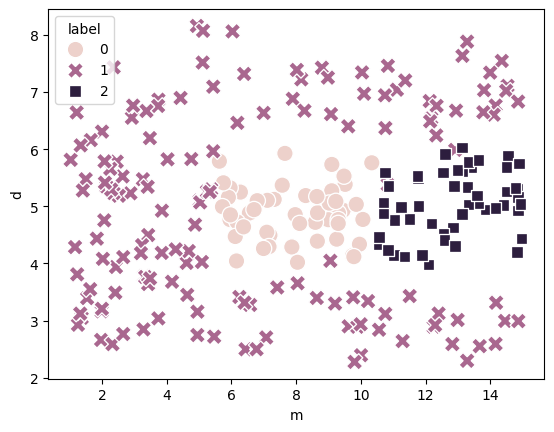

In [4]:
import matplotlib.pyplot as plt

# check number of classes
df.label.unique()

# Data Visualization
sns.scatterplot(x='m', y='d', data=df, hue='label', style='label', s=140)
plt.show()

Nomalization

In [5]:
# define data
X = df.drop('label', axis=1)
y = df.label

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# Nomalization ( X_train: numpy array )
X_train = sc.fit_transform(X)   # X for train

# y_train:  pandas.core.series.Series
y_train = y                     # y for train

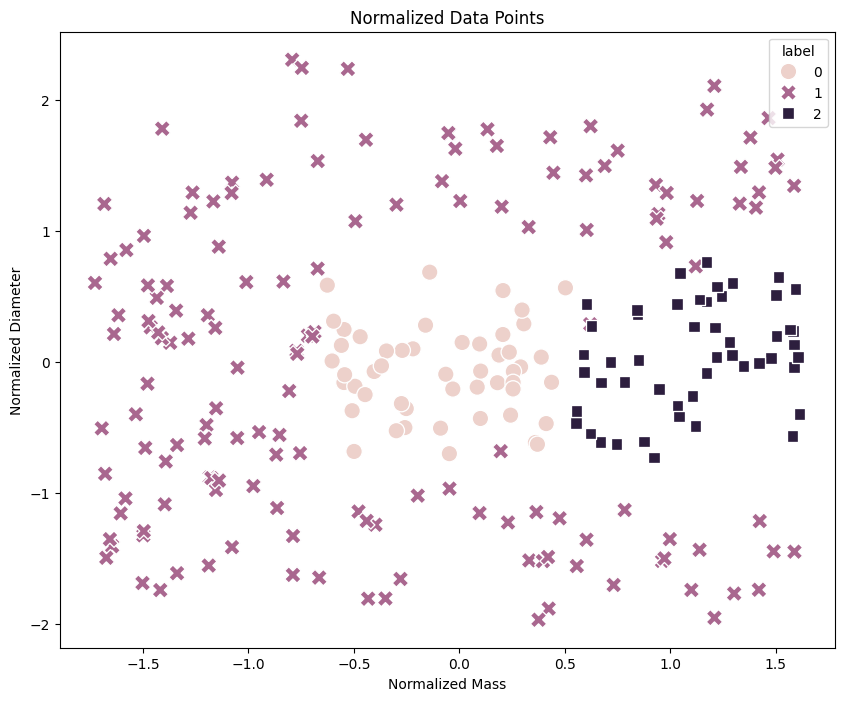

In [6]:
# Visualization after Nomalization

# Create a DataFrame from X_train and y_train_array
df_sc = pd.DataFrame(X_train, columns=['m','d'])
df_sc['label'] = y_train

# Create the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='m', y='d', data=df_sc, hue='label', style='label', s=140)
plt.title('Normalized Data Points')
plt.xlabel('Normalized Mass')
plt.ylabel('Normalized Diameter')
plt.show()

Create Neural Network Model

Note

remind iteration is first thing to just

First step : start with low hidden layers node (4) and hight iteration

Second step : if loss curve is good. So don't need to increase iterations and can adjust only hidden layer nodes 


If Boundary is not good. can improve by increasing hidden layer node
If accuracy is not good. can improve by increasing iterations

In [7]:
from sklearn.neural_network import MLPClassifier

hidden =  150 # Default: 100 
iter = 200 # Default: 200

# Define model

# Case 1 Normal (Defalut)
# model = MLPClassifier(random_state=1)
# Case 2 Increase Iteration ( Cause the loss curve can be improved)
# model = MLPClassifier(max_iter=1000,random_state=1, verbose=True)

# First Step
# Case 3 Increase More Iteration but decrease hidden layer node
# model = MLPClassifier(hidden_layer_sizes=4,max_iter=2500,random_state=1, verbose=True)

# Second Step
# Case 4 Increase hidden layer nodes
model = MLPClassifier(hidden_layer_sizes=20,max_iter=2500,random_state=1, verbose=True)

# Train the model
model.fit(X_train, y_train)

Iteration 1, loss = 0.92615553
Iteration 2, loss = 0.91517415
Iteration 3, loss = 0.90494625
Iteration 4, loss = 0.89476533
Iteration 5, loss = 0.88517273
Iteration 6, loss = 0.87545560
Iteration 7, loss = 0.86648728
Iteration 8, loss = 0.85754228
Iteration 9, loss = 0.84897683
Iteration 10, loss = 0.84041397
Iteration 11, loss = 0.83244293
Iteration 12, loss = 0.82468563
Iteration 13, loss = 0.81693822
Iteration 14, loss = 0.80983104
Iteration 15, loss = 0.80255471
Iteration 16, loss = 0.79576412
Iteration 17, loss = 0.78914753
Iteration 18, loss = 0.78289810
Iteration 19, loss = 0.77687971
Iteration 20, loss = 0.77083017
Iteration 21, loss = 0.76514852
Iteration 22, loss = 0.75976567
Iteration 23, loss = 0.75435775
Iteration 24, loss = 0.74936571
Iteration 25, loss = 0.74436458
Iteration 26, loss = 0.73944796
Iteration 27, loss = 0.73481620
Iteration 28, loss = 0.73019076
Iteration 29, loss = 0.72594852
Iteration 30, loss = 0.72149632
Iteration 31, loss = 0.71734027
Iteration 32, los

MLPClassifier(hidden_layer_sizes=20, max_iter=2500, random_state=1,
              verbose=True)

Show Result

In [8]:
print('score:', round(model.score(X_train,y_train),4))

print('annual y:', np.array(y))
print('predicted: ', model.predict(X_train))

score: 0.984
annual y: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
predicted:  [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 

Show Loss Curve

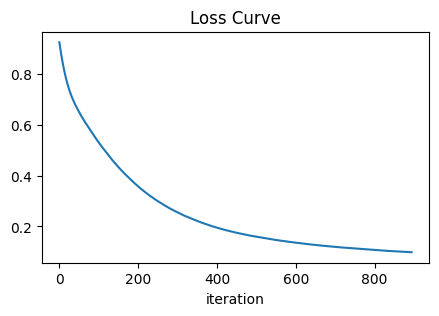

In [9]:
plt.figure(figsize=(5,3))
plt.title('Loss Curve')
plt.xlabel('iteration')
plt.plot(model.loss_curve_)
plt.show()

Show model construction

In [10]:
[coef.shape for coef in model.coefs_]

[(2, 20), (20, 3)]

Display decision area

<Axes: >

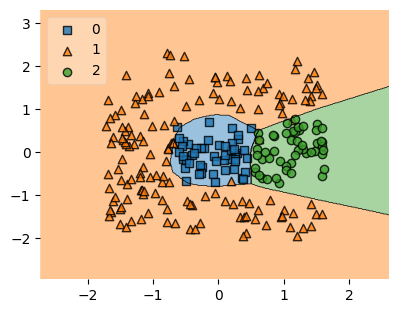

In [11]:
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(4.5,3.5))
plot_decision_regions(X_train, np.array(y_train), clf=model, legend=2)
# plt.xticks([])
# plt.yticks([])
# plt.xlabel('m (gram)')
# plt.ylabel('d (diameter)')
# plt.show()


Predictions

In [12]:
# from sklearn.preprocessing import StandardScaler
# sc = StandardScaler()

X_new = [[2.4, 7],
         [8.1,5.2],
         [11.1,5.5]]

X_new_sc = sc.transform(X_new)

prediction = model.predict(X_new_sc)
print(prediction)

[1 0 2]


c:\Users\UNS_CT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Show result predictions

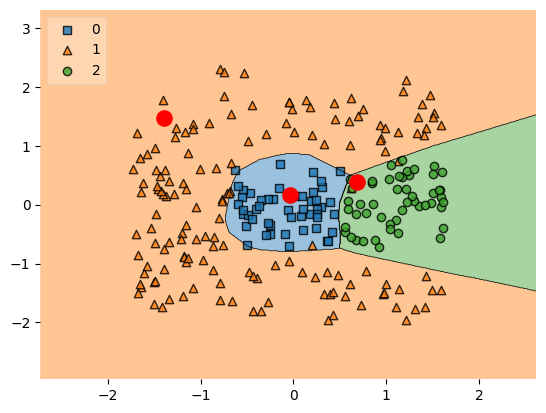

In [13]:
# Boundary predictions model
plot_decision_regions(X_train, np.array(y_train), clf=model, legend=2)


# X_new_sc point
plt.scatter(X_new_sc[:,0], X_new_sc[:,1], marker="o", s=120, c='r')
plt.show()